# Tutorial 6: Assign Mask Labels & Split Traces

## Objective

In many chromatin tracing experiments, you want to separate traces based on **spatial regions** defined by a segmentation mask (e.g. a nuclear marker, a tissue boundary, or an immunofluorescence signal).

This tutorial covers two complementary tools:

1. **`trace_assign_mask`** — reads a 2D mask image and tags each spot in a trace file with a label if its (x, y) position falls inside the mask.
2. **`trace_split_labels`** — splits a labeled trace file into two separate files: spots **with** the label and spots **without** it.

## When to use this

- You have a **2D mask** (`.tif` or `.npy`) that delineates a region of interest (e.g. a nuclear compartment, a specific cell type marker).
- You want to compare chromatin organization **inside** vs. **outside** that region.
- Typical workflow: assign mask → split → run separate analyses on each population.

## Input files

| File | Description |
|------|-------------|
| `Trace_3D_barcode_mask-mask0_ROI-16.ecsv` | A trace file (already filtered) |
| `MAX_scan_003_RT23_016_ROI.tif` | A 2D mask image (e.g. MAX projection of an IF channel) |

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel"

input_trace = f"{data_path}/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51.ecsv"
mask_file ="/mnt/aguila/AnalyzedData_2025/Experiment_148_Christel_DNAFISH_NippedB_slide1_HR38_Bx/pyhim_analysis_hr38/051/mask_2d/data/scan_002_mask0_051_ROI_converted_decon_ch01_Masks.npy"

print(f"Trace file: {input_trace}")
print(f"Mask file:  {mask_file}")

Trace file: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51.ecsv
Mask file:  /mnt/aguila/AnalyzedData_2025/Experiment_148_Christel_DNAFISH_NippedB_slide1_HR38_Bx/pyhim_analysis_hr38/051/mask_2d/data/scan_002_mask0_051_ROI_converted_decon_ch01_Masks.npy


## Step 1: Assign mask labels with `trace_assign_mask`

The `trace_assign_mask` command reads each spot's (x, y) coordinates, converts them to pixel positions
using `--pixel_size`, and checks whether the corresponding pixel in the mask has a value ≥ 1.

- If **inside the mask** → the label (here `Pdx1`) is appended to the spot's `label` column.
- If **outside** → the `label` column is left unchanged.

### Key parameters

| Option | Default | Description |
|--------|---------|-------------|
| `--input` | — | Input trace file (ECSV) |
| `--mask_file` | — | 2D mask image (`.tif`, `.tiff`, or `.npy`) |
| `--label` | `"labeled"` | Name to assign to spots inside the mask |
| `--pixel_size` | `0.1` | Lateral pixel size in microns (must match your imaging setup) |

In [16]:
!trace_assign_mask --input {input_trace} --mask_file {mask_file} --label xxxxxxxxxxxxxxxxxxxx

------- Running trace_assign_mask.py --------
Assign mask labels to traces using numpy masks.

==========Started execution==========

1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51.ecsv
$ mask image file read: /mnt/aguila/AnalyzedData_2025/Experiment_148_Christel_DNAFISH_NippedB_slide1_HR38_Bx/pyhim_analysis_hr38/051/mask_2d/data/scan_002_mask0_051_ROI_converted_decon_ch01_Masks.npy

> 1397 trace rows out of 20859 were associated to mask xxxxxxxxxxxxxxxxxxxx. Unique traces: 393
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx.ecsv ...
$ Saved output trace file at: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_m

This produces two output files next to the input:

| Output | Description |
|--------|-------------|
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1.ecsv` | Trace file with `label` column updated |
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_mask_plot.png` | Diagnostic plot showing assignment |

## Step 2: Inspect the mask assignment plot

The diagnostic plot overlays spot positions on the mask image:
- **Red dots**: spots **inside** the mask (labeled `Pdx1`)
- **Cyan dots**: spots **outside** the mask (unlabeled)

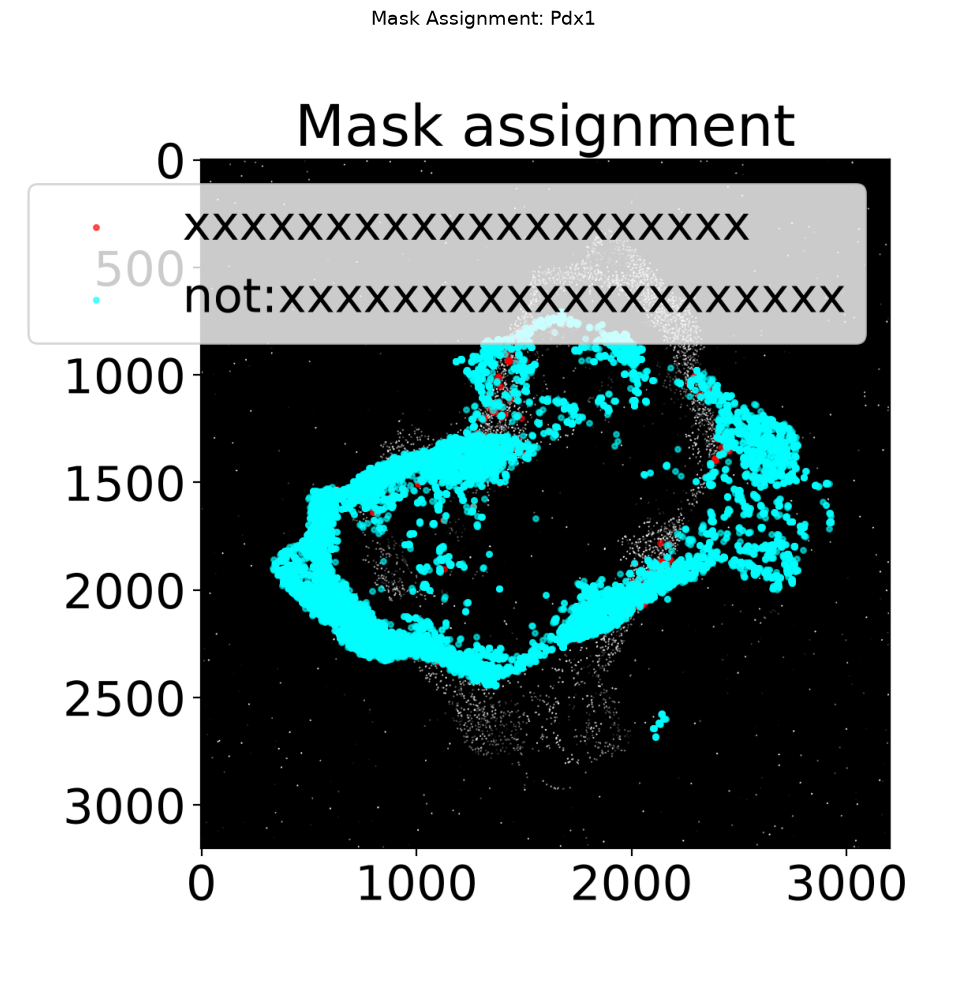

In [20]:
plot_file = f"{data_path}/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_mask_plot.png"

img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
ax.set_title("Mask Assignment: Pdx1", fontsize=14)
plt.tight_layout()
plt.show()

**What to check:**
- Do the red spots align well with the mask boundaries?
- If spots appear shifted, verify that `--pixel_size` matches your microscope calibration.
- If spots fall outside the image, the mask dimensions may not match the field of view.

## Step 3: Split traces by label with `trace_split_labels`

Now that spots are labeled, use `trace_split_labels` to separate the trace file into two populations:

1. **Spots with the label** (`Pdx1`) — inside the mask
2. **Spots without the label** (`not:Pdx1`) — outside the mask

This creates two independent ECSV files that can be analyzed separately (e.g. compute Hi-M matrices, barcode statistics, etc.).

In [26]:
# Split the labeled trace file
labeled_trace = f"{data_path}/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx.ecsv"

!trace_split_labels --input {labeled_trace} --label xxxxxxxxxxxxxxxxxxxx

------- Running trace_split_labels.py --------
Split a trace file into two files based on the presence of a label.

========== Started execution ==========

$ Processing 1 trace file(s)

> Processing: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx.ecsv
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_xxxxxxxxxxxxxxxxxxxx.ecsv ...
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_not:xxxxxxxxxxxxxxxxxxxx.ecsv ...
$ Saved: /mnt/grey/DATA/users/zidoum/traceraptops/jupyterlab_amel/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxx

This produces two files:

| Output file | Content |
|-------------|----------|
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_Pdx1.ecsv` | Spots **inside** the mask (label contains `Pdx1`) |
| `Trace_3D_barcode_mask-mask0_ROI-16_Pdx1_not:Pdx1.ecsv` | Spots **outside** the mask (label does not contain `Pdx1`) |

Each file is a valid trace ECSV that can be used directly in downstream analysis pipelines
(e.g. `trace_to_matrix`, `plot_him_matrix`, `trace_analyzer`).

## Step 4: Verify the split

In [27]:
import os

inside_file = f"{data_path}/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_xxxxxxxxxxxxxxxxxxxx.ecsv"
outside_file = f"{data_path}/ROI_51/Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_not:xxxxxxxxxxxxxxxxxxxx.ecsv"

for name, path in [("Inside mask (Pdx1)", inside_file), ("Outside mask (not:Pdx1)", outside_file)]:
    if os.path.exists(path):
        # Count data lines (skip ECSV header)
        with open(path) as f:
            lines = [l for l in f if not l.startswith('#') and l.strip()]
        n_data = len(lines) - 1  # subtract column header
        print(f"{name}: {n_data} spots  ({os.path.basename(path)})")
    else:
        print(f"{name}: FILE NOT FOUND")

Inside mask (Pdx1): 1397 spots  (Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_xxxxxxxxxxxxxxxxxxxx.ecsv)
Outside mask (not:Pdx1): 19462 spots  (Trace_3D_barcode_mask-mask0_ROI-51_xxxxxxxxxxxxxxxxxxxx_not:xxxxxxxxxxxxxxxxxxxx.ecsv)


## Summary

### Workflow

```
trace file + 2D mask
       │
       ▼
trace_assign_mask --label Pdx1     →  labeled trace + diagnostic PNG
       │
       ▼
trace_split_labels --label Pdx1    →  inside.ecsv + outside.ecsv
```

### Commands reference

```bash
# 1. Assign mask labels
trace_assign_mask --input Trace.ecsv --mask_file mask.tif --label Pdx1

# 2. Split by label
trace_split_labels --input Trace_Pdx1.ecsv --label Pdx1
```

### Notes

- The mask must be **2D** (a single plane). If your mask is 3D, take a MAX projection first.
- The `--pixel_size` default is `0.1` µm/pixel. Adjust this if your microscope calibration differs.
- You can assign **multiple labels** by running `trace_assign_mask` several times with different masks and label names. The labels accumulate in the `label` column (comma-separated).
- `trace_split_labels` uses string matching: it checks whether the label text appears anywhere in the `label` column, so it works correctly even with multiple comma-separated labels.

**Next:** [Tutorial 7 — Build Contact Matrices](tutorial_07_matrix_visualization.ipynb)